# **AI Startup Evaluation System - Architecture Notebook**

### **Introduction**

This notebook explains the architecture and workflow of the AI Startup Evaluation System built using:
LangGraph
LangChain
Ollama
FAISS Vector Store
Gradio
SQLite Memory
Multi-Agent Workflow Architecture

The project simulates how venture capital firms evaluate startup ideas using multiple specialized AI agents.

## **1. Project Workflow Architecture**
**Multi-Agent Workflow**

The system is implemented as a graph-based workflow using LangGraph.

Each node represents a specialized AI agent:

Market Analysis Agent
Competitor Analysis Agent
SWOT Analysis Agent
Financial Risk Agent
Final Decision Agent

The workflow supports:

Sequential execution
Conditional routing
Shared state management
Persistent memory
RAG-based retrieval

### **Architecture Graph**

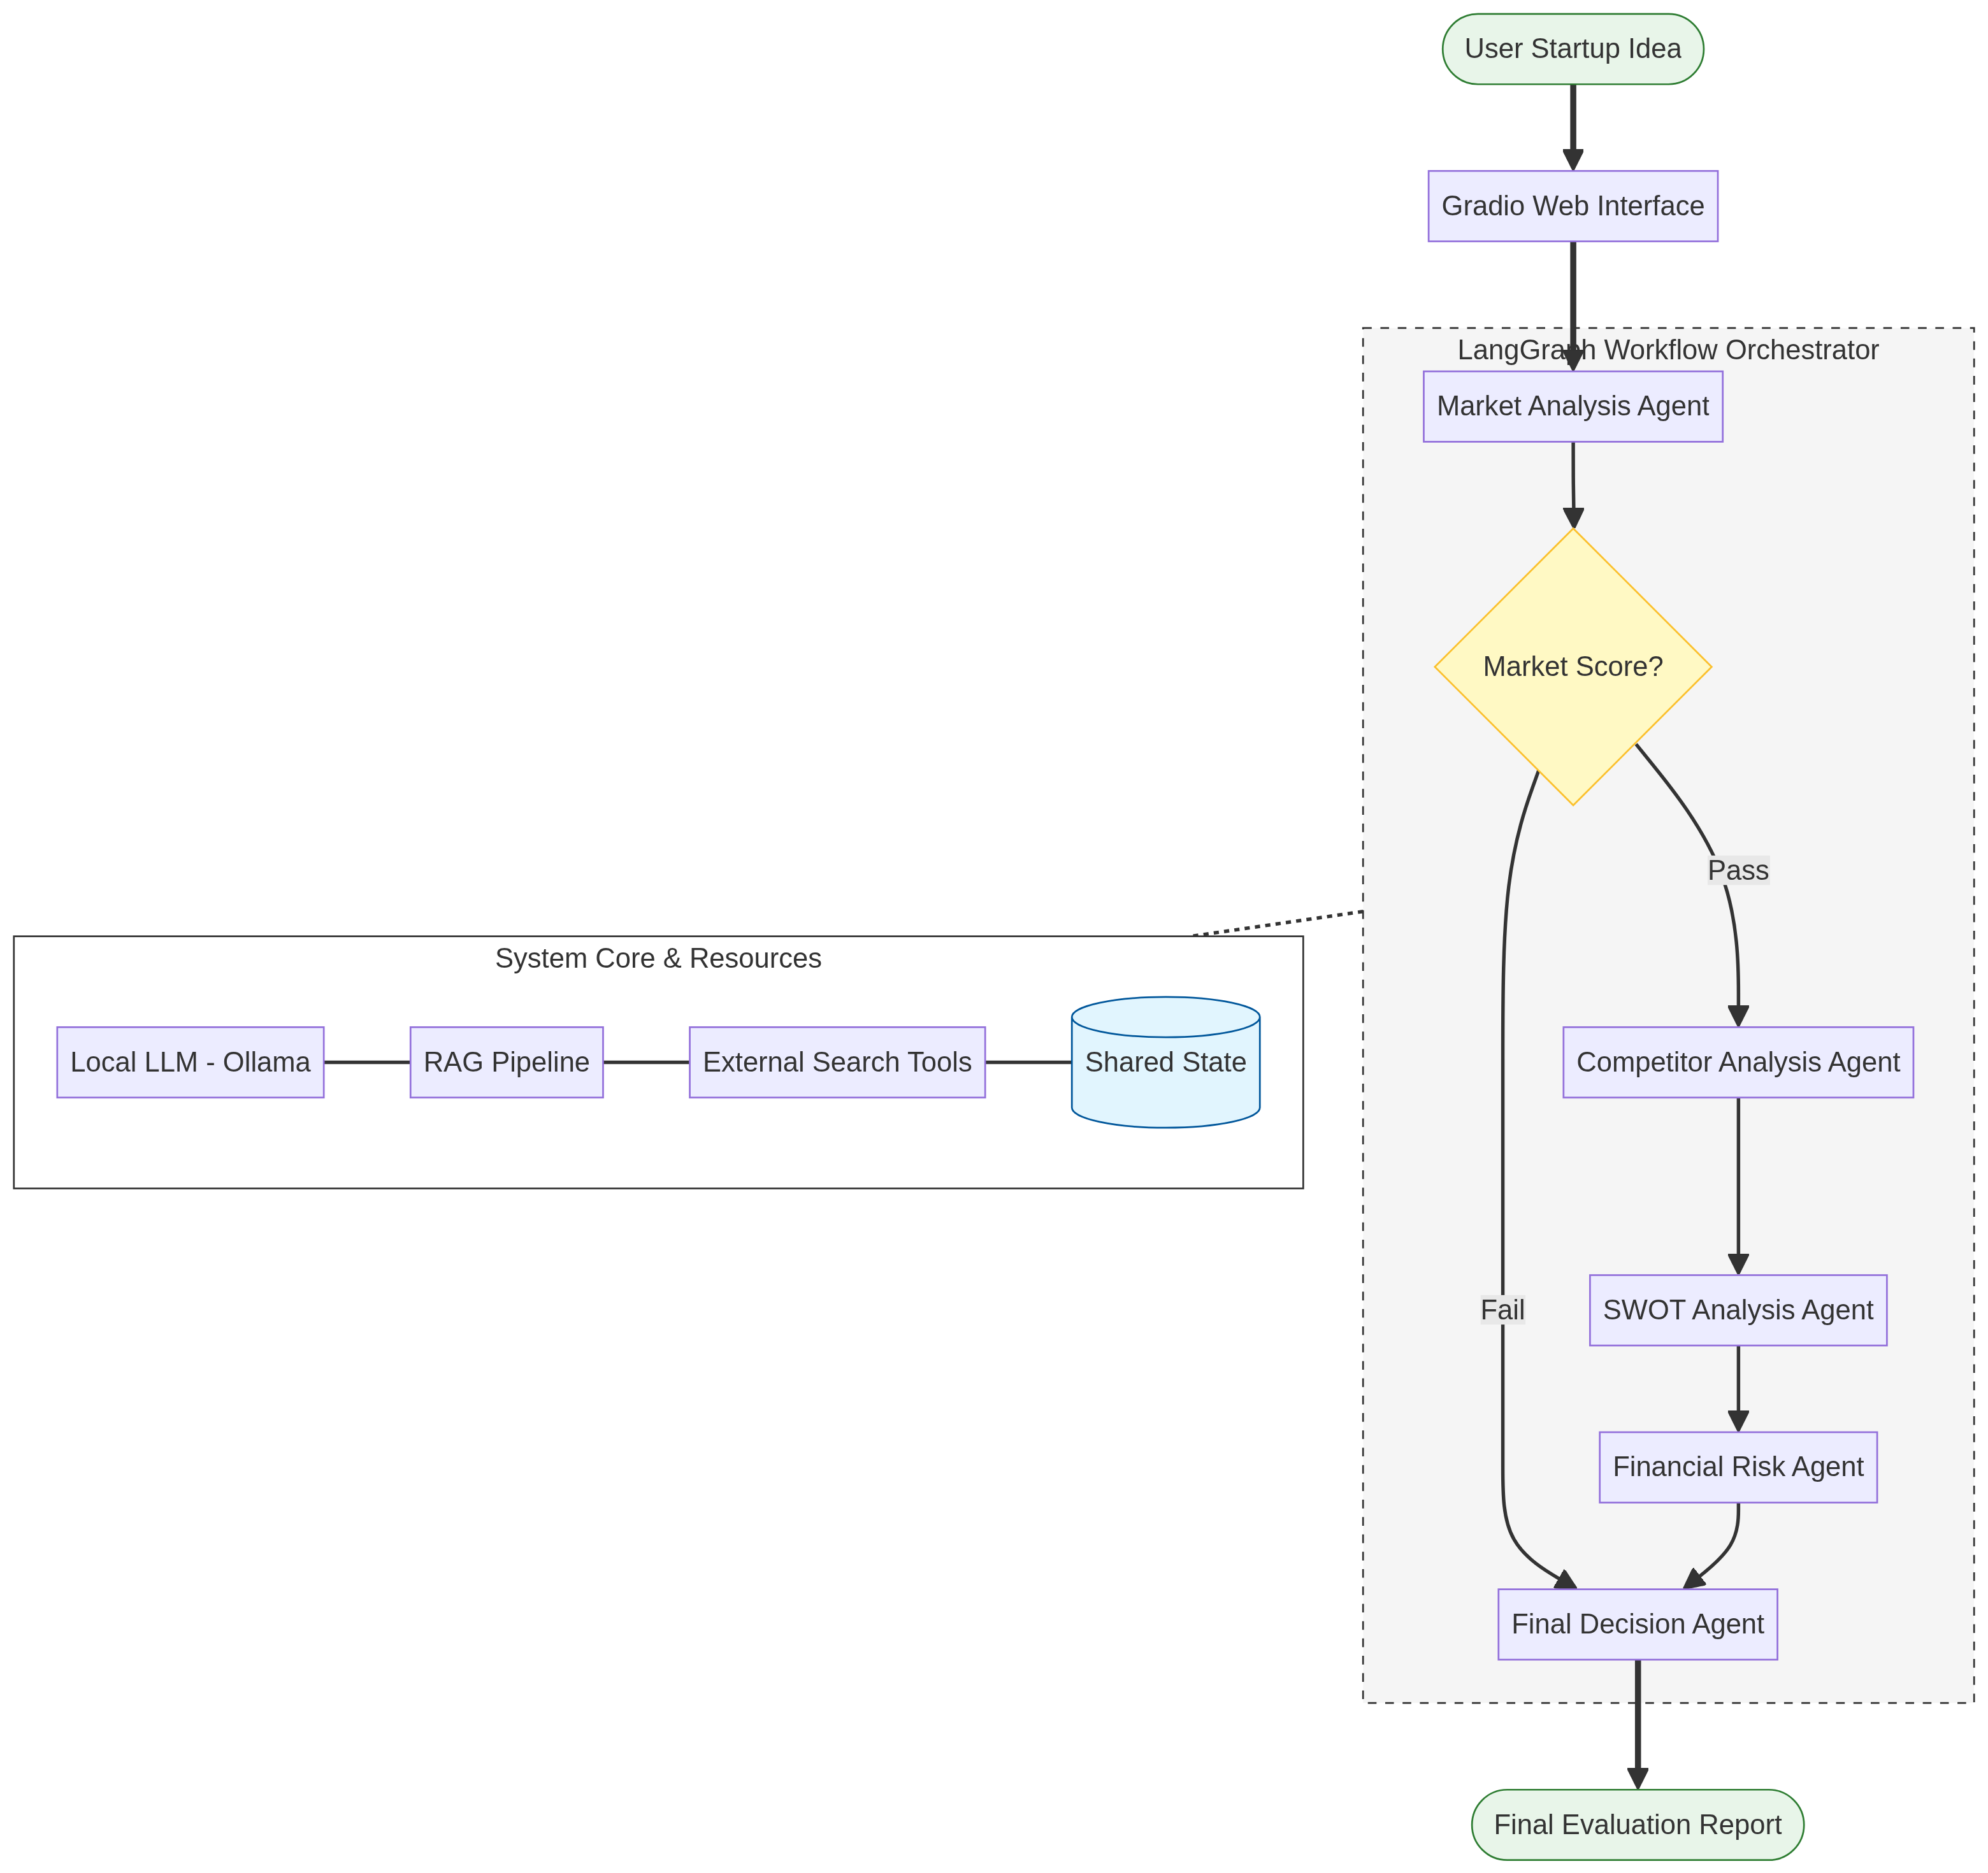

In [2]:
from IPython.display import Image

Image(filename="graph.png")

## **2. State Management**
**Shared State**

The project uses a centralized shared state called StartupState.

This state stores all intermediate results generated by the agents.

**State Definition**

In [ ]:
from typing import TypedDict, List, Dict, Any

class StartupState(TypedDict):
    idea: str

    market_analysis: str
    competitor_analysis: str
    swot_analysis: str
    financial_risk_analysis: str

    market_score: int

    investment_score: float
    final_decision: str

    messages: Annotated[List[Dict[str, Any]], add]

**Purpose of Shared State**

Enables communication between agents
Preserves workflow continuity
Stores intermediate outputs
Maintains memory during execution

## **3. LangGraph Workflow**
**Workflow Creation**

The workflow is implemented using StateGraph.

In [ ]:
from langgraph.graph import StateGraph
from app.graph.state import StartupState

graph = StateGraph(StartupState)

**Adding Nodes**

Each node represents an independent AI agent

In [ ]:
graph.add_node("market_analysis", market_agent)
graph.add_node("competitor_analysis", competitor_agent)
graph.add_node("swot_analysis", swot_agent)
graph.add_node("financial_risk_analysis", financial_agent)
graph.add_node("final_decision", final_decision_agent)

**Sequential Edges**

Sequential edges define the normal execution flow.

In [ ]:
graph.add_edge("competitor_analysis", "swot_analysis")
graph.add_edge("swot_analysis", "financial_risk_analysis")
graph.add_edge("financial_risk_analysis", "final_decision")

## **4. Conditional Routing**

The workflow dynamically changes execution based on the market score.

If:

Market Score < 50 → Skip remaining analysis
Market Score >= 50 → Continue full workflow


**Conditional Routing Function**

In [ ]:
def route_after_market(state):
    score = state.get("market_score", 50)

    if score < 50:
        return "final_decision"

    return "competitor_analysis"

**Conditional Edge Registration**

In [ ]:
graph.add_conditional_edges(
    "market_analysis",
    route_after_market,
    {
        "competitor_analysis": "competitor_analysis",
        "final_decision": "final_decision"
    }
)

## **5. Retrieval-Augmented Generation (RAG)**
**RAG Pipeline Overview**

The system uses Retrieval-Augmented Generation (RAG) to improve factual grounding.

Instead of relying only on LLM knowledge, the agents retrieve relevant business knowledge from a vector database.

**Loading the Vector Store**

In [ ]:
from langchain_community.vectorstores import FAISS
from langchain_ollama import OllamaEmbeddings
from langchain_community.document_loaders import TextLoader

loader = TextLoader("data/business_knowledge.txt")
docs = loader.load()

embeddings = OllamaEmbeddings(model="llama3.2")

vectorstore = FAISS.from_documents(docs, embeddings)

**Retrieval Step**

In [ ]:
retriever = vectorstore.as_retriever()

docs = retriever.invoke(idea)

context = "\n\n".join([d.page_content for d in docs])

## **6. ReAct Agents + Web Search**
The project integrates external tools using:

Tavily Search API
LangGraph ReAct Agents

This allows agents to:

Search live market data
Analyze competitors
Estimate financial costs

**Tool Initialization**

In [ ]:
from langchain_tavily import TavilySearch

web_search_tool = TavilySearch(max_results=3)
tools = [web_search_tool]

**ReAct Agent Creation**

In [ ]:
from langgraph.prebuilt import create_react_agent

agent = create_react_agent(llm, tools)

## **7. SQLite Persistent Memory**

The project uses SQLite as persistent memory storage.

This enables:

Session persistence
Conversation continuity
Workflow recovery
Thread-based memory

**SQLite Checkpointer**

In [ ]:
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3

conn = sqlite3.connect("checkpoints.db", check_same_thread=False)
memory = SqliteSaver(conn)

**Compiling Workflow with Memory**

In [ ]:
workflow = graph.compile(checkpointer=memory)

## **8. Gradio User Interface**

The project includes a Gradio-based interactive interface.

Features include:

Startup idea submission
Agent-by-agent analysis tabs
Investment score display
PDF report generation

**Gradio Interface Example**

In [ ]:
with gr.Blocks(title="AI Startup Evaluator") as demo:

    gr.Markdown("# 🚀 AI Startup Evaluator")

    idea_input = gr.Textbox(
        label="Startup Idea"
    )

    submit_btn = gr.Button("Evaluate 🚀")

## **9. Final Decision Logic**

The final agent generates:

Investment Score
Recommendation
Reasoning

Possible recommendations:

Invest
Consider
Avoid

## **10. Key Technologies Used**

**Technology**	**||**  **Purpose**

LangGraph   **||**	Workflow orchestration

LangChain    **||**| 	LLM integration

Ollama	    **||**    Local LLM hosting

FAISS	   **||**   Vector database

Tavily      **||**	Web search

SQLite     **||**	Persistent memory

Gradio   **||**    	User interface

## **11. Conclusion**

This project demonstrates a complete AI agentic workflow architecture using modern LLM engineering techniques.

The system combines:

Multi-agent orchestration

Conditional routing

RAG pipelines

Persistent memory

External tools

Interactive UI

The architecture is modular, scalable, and extensible for future AI systems.